In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("ecommerce_customer_behavior_dataset_v2.csv")

In [3]:
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [4]:
df.shape

(17049, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

In [6]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Date,0
Age,0
Gender,0
City,0
Product_Category,0
Unit_Price,0
Quantity,0
Discount_Amount,0


In [7]:
unique_customer_ids = df['Customer_ID'].unique()
print(unique_customer_ids)

['CUST_00001' 'CUST_00002' 'CUST_00003' ... 'CUST_04998' 'CUST_04999'
 'CUST_05000']


In [8]:
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000
mean,34.945745,447.901689,3.011379,69.788135,1277.438711,14.535633,9.003109,6.503607,3.899408
std,11.046855,722.319705,1.417027,240.704662,2358.436375,2.925524,2.259954,3.488787,1.128803
min,18.000000,5.050000,1.000000,0.000000,6.210000,4.000000,1.000000,1.000000,1.000000
25%,26.000000,73.260000,2.000000,0.000000,172.970000,13.000000,7.000000,4.000000,3.000000
50%,35.000000,174.680000,3.000000,0.000000,455.850000,15.000000,9.000000,6.000000,4.000000
75%,42.000000,494.570000,4.000000,32.710000,1267.750000,17.000000,11.000000,8.000000,5.000000
max,75.000000,7900.010000,5.000000,6538.290000,37852.050000,26.000000,18.000000,25.000000,5.000000


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

def get_satisfaction(customer_rating):
  if customer_rating >= 4:
    return 'satisfied and meet their requirements'
  elif customer_rating >= 3:
    return 'neutral'
  else:
    return 'not satisfied'

df['Satisfaction level'] = df['Customer_Rating'].apply(get_satisfaction)
print(df.head())

       Order_ID Customer_ID       Date  Age Gender      City Product_Category  \
0  ORD_000001-1  CUST_00001 2023-05-29   40   Male    Ankara            Books   
1  ORD_000001-2  CUST_00001 2023-10-12   40   Male    Ankara    Home & Garden   
2  ORD_000001-3  CUST_00001 2023-12-05   40   Male    Ankara           Sports   
3  ORD_000002-1  CUST_00002 2023-05-11   33   Male  Istanbul             Food   
4  ORD_000002-2  CUST_00002 2023-06-16   33   Male  Istanbul           Beauty   

   Unit_Price  Quantity  Discount_Amount  Total_Amount  Payment_Method  \
0       29.18         1             0.00         29.18  Digital Wallet   
1      644.40         1           138.05        506.35     Credit Card   
2      332.82         5             0.00       1664.10     Credit Card   
3       69.30         5            71.05        275.45  Digital Wallet   
4      178.15         3             0.00        534.45     Credit Card   

  Device_Type  Session_Duration_Minutes  Pages_Viewed  Is_Returning_

In [10]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Total_Amount'].fillna(df['Total_Amount'].median(), inplace=True)
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
df['Customer_Rating'].fillna(df['Customer_Rating'].median(), inplace=True)
print(df[['Age','Total_Amount','Quantity','Customer_Rating']])

       Age  Total_Amount  Quantity  Customer_Rating
0       40         29.18         1                4
1       40        506.35         1                2
2       40       1664.10         5                4
3       33        275.45         5                4
4       33        534.45         3                4
...    ...           ...       ...              ...
17044   44        137.30         2                1
17045   24        156.12         1                5
17046   24       3195.72         3                4
17047   24         86.66         2                2
17048   24       3843.91         4                4

[17049 rows x 4 columns]


Text(0, 0.5, 'Frequency')

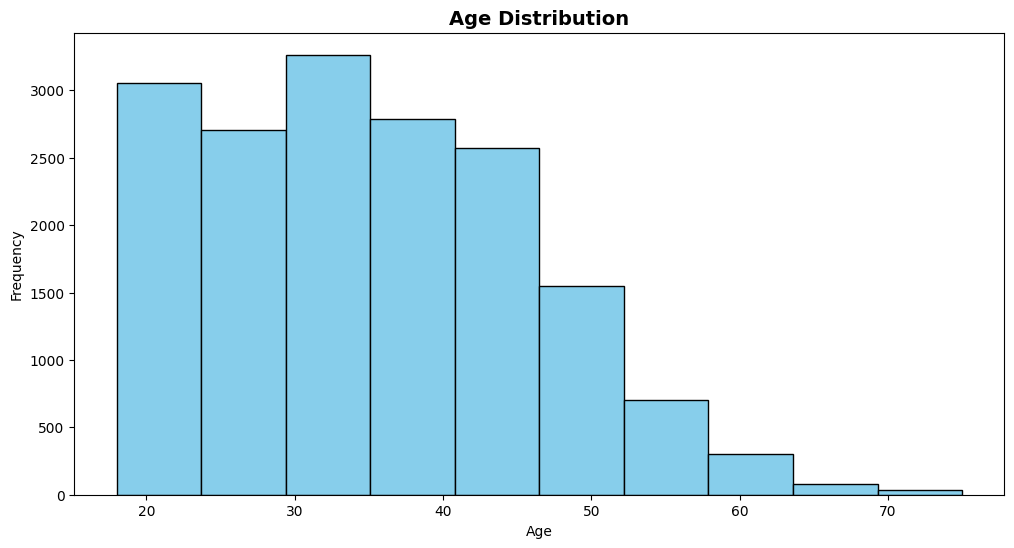

In [11]:
plt.figure(figsize=(12, 6))
plt.hist(df['Age'], color='skyblue', edgecolor='black')
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

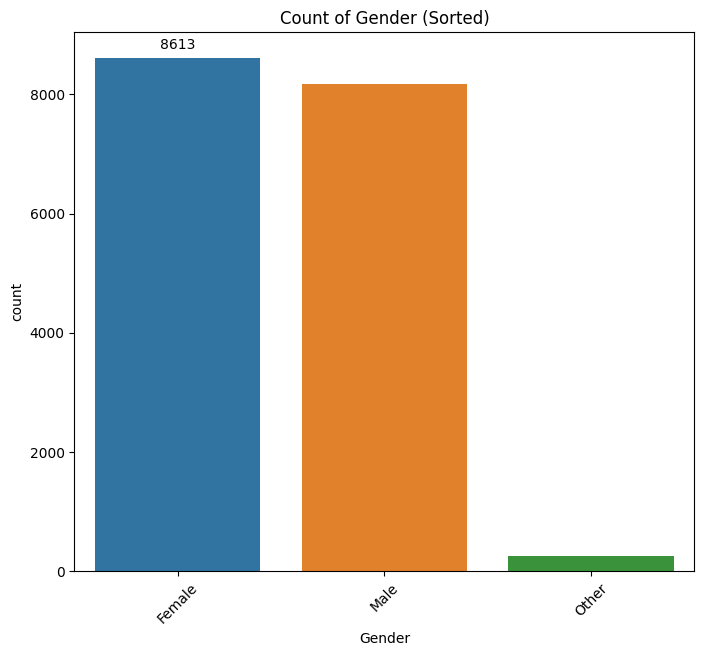

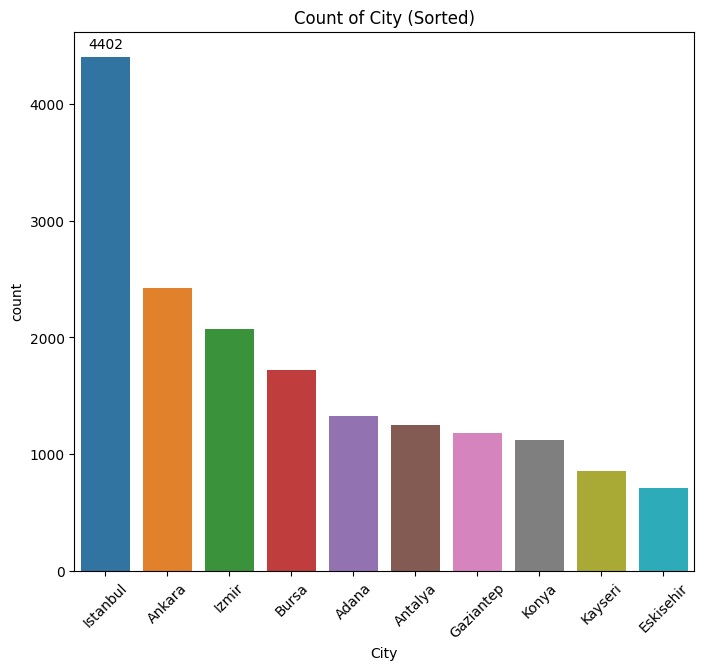

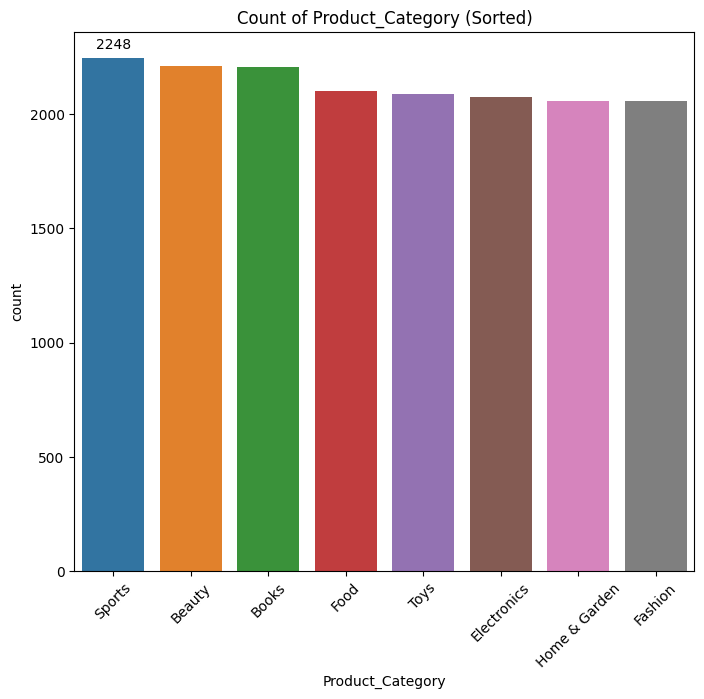

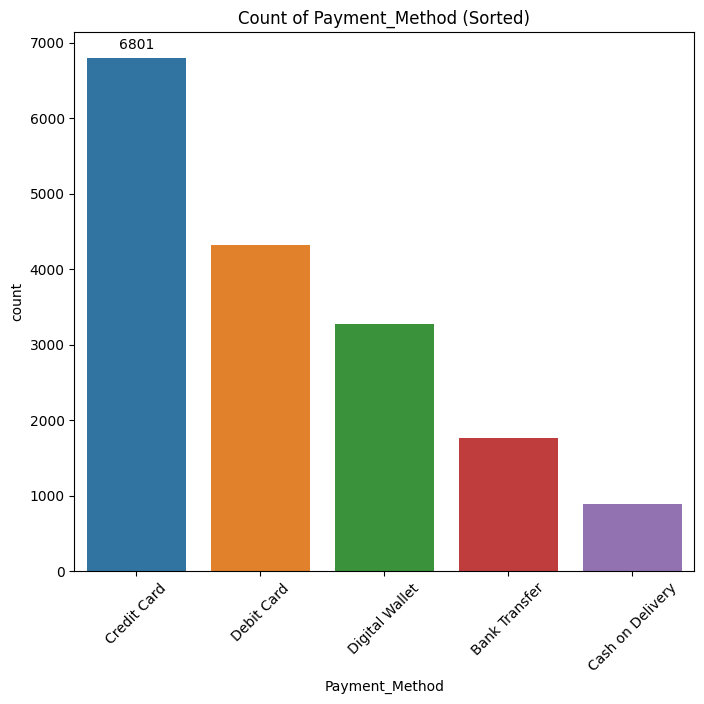

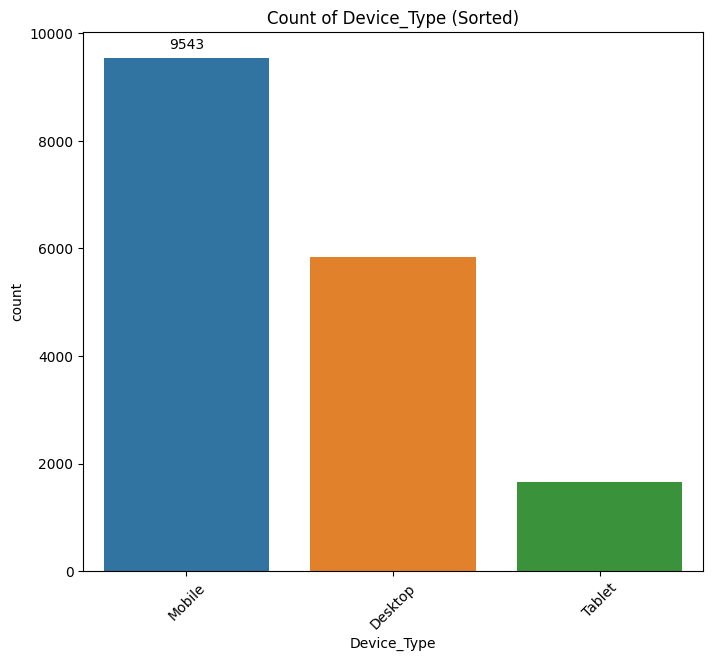

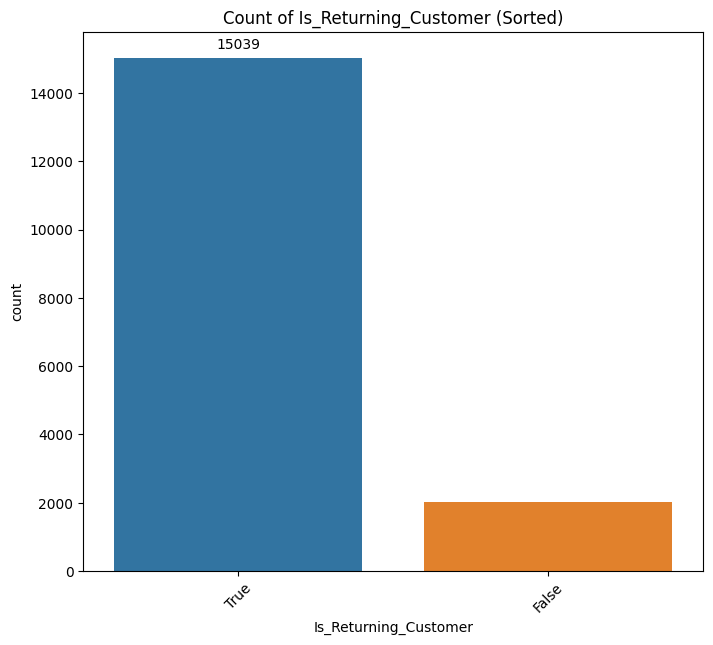

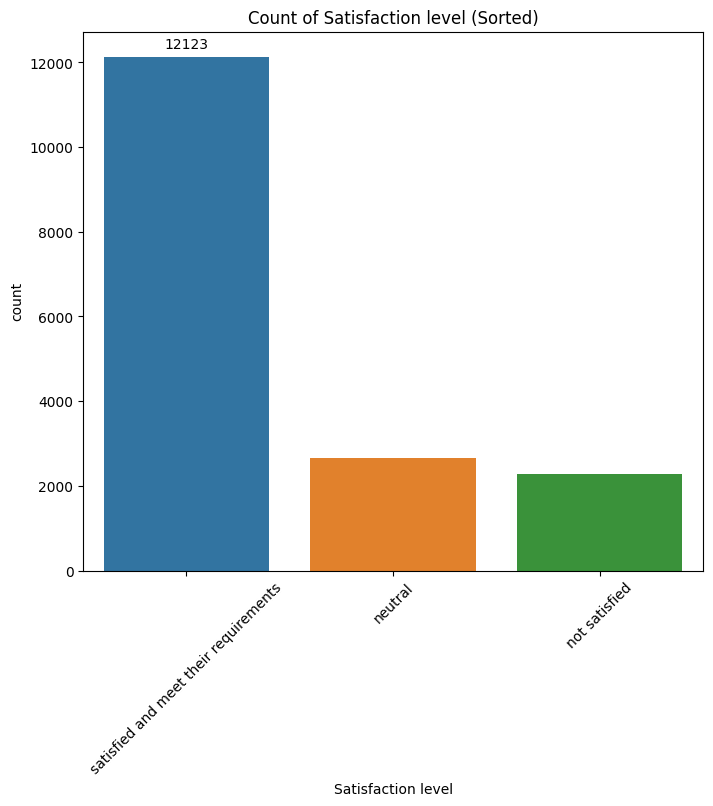

In [12]:
cat_cols = ['Gender', 'City', 'Product_Category', 'Payment_Method', 'Device_Type', 'Is_Returning_Customer', 'Satisfaction level']
for col in cat_cols:
    plt.figure(figsize=(8, 7))
    order = df[col].value_counts().index
    ax = sns.countplot(x=col, data=df, palette='tab10', order=order)
    ax.bar_label(ax.containers[0], padding=4)
    plt.title(f'Count of {col} (Sorted)')
    plt.xticks(rotation=45)
    plt.show()

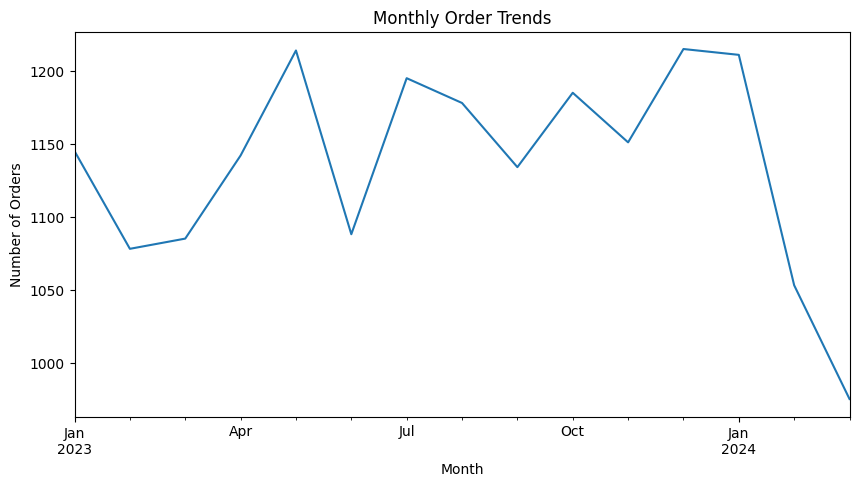

In [13]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_orders = df.groupby('Month').size()
plt.figure(figsize=(10,5))
monthly_orders.plot(kind='line')
plt.title('Monthly Order Trends')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

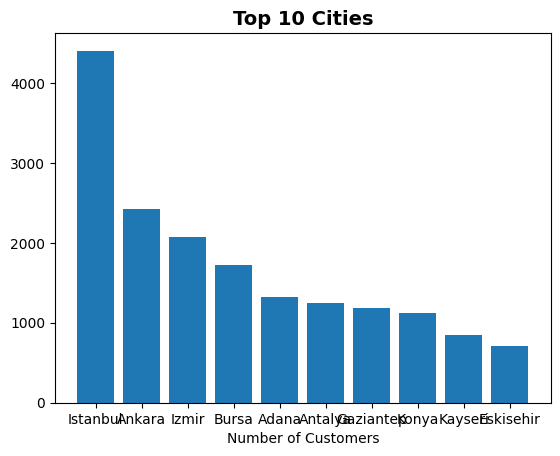

In [14]:
city_counts = df['City'].value_counts().head(10)
plt.bar(city_counts.index, city_counts.values)
plt.title('Top 10 Cities', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Electronics'),
  Text(1, 0, 'Home & Garden'),
  Text(2, 0, 'Sports'),
  Text(3, 0, 'Fashion'),
  Text(4, 0, 'Toys'),
  Text(5, 0, 'Beauty'),
  Text(6, 0, 'Food'),
  Text(7, 0, 'Books')])

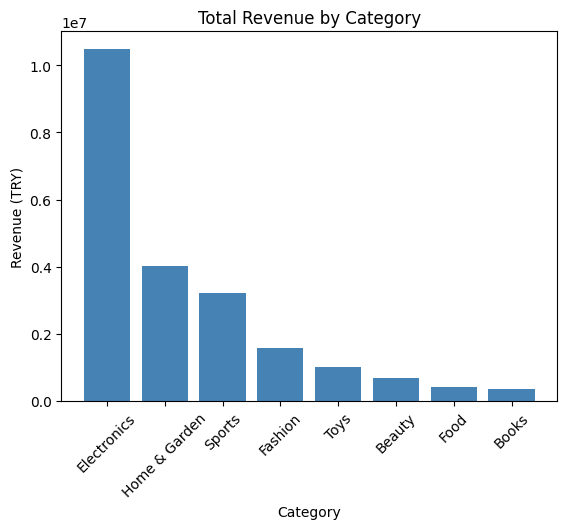

In [15]:
category_revenue = df.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=False)
plt.bar(category_revenue.index, category_revenue.values, color='steelblue')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue (TRY)')
plt.xticks(rotation=45)

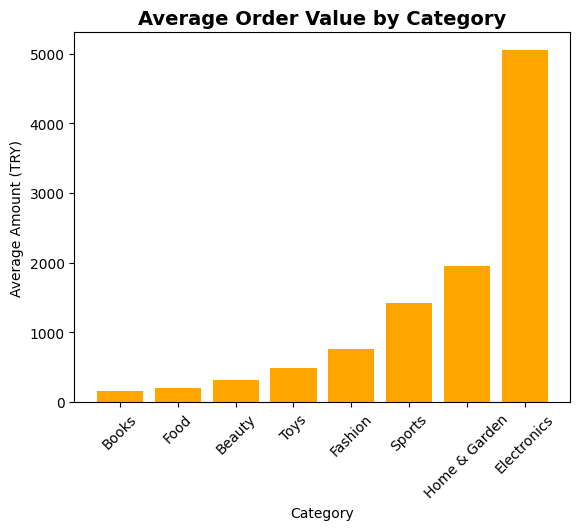

In [16]:
avg_order = df.groupby('Product_Category')['Total_Amount'].mean().sort_values(ascending=True)
plt.bar(avg_order.index, avg_order.values, color='orange')
plt.title('Average Order Value by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Average Amount (TRY)')
plt.xticks(rotation=45)
plt.show()

In [17]:
category_stats = df.groupby('Product_Category').agg(
    Total_Revenue=('Total_Amount', 'sum'),
    Avg_Order_Value=('Total_Amount', 'mean'),
    Orders=('Order_ID', 'count'),
    Avg_Rating=('Customer_Rating', 'mean'),
    Total_Units=('Quantity', 'sum')
)
category_stats = category_stats.sort_values('Total_Revenue', ascending=True)
print("Category Performance:")
category_stats

Category Performance:


,Total_Revenue,Avg_Order_Value,Orders,Avg_Rating,Total_Units
Product_Category,,,,,
Books,360399.11,163.372217,2206,3.881233,6727
Food,422054.65,200.691702,2103,3.862577,6381
Beauty,694437.02,313.940787,2212,3.921338,6564
Toys,1014237.53,485.281115,2090,3.895215,6303
Fashion,1577035.70,767.040710,2056,3.887160,6078
Sports,3205086.99,1425.750440,2248,3.918149,6856
Home & Garden,4023903.94,1953.351427,2060,3.930097,6155
Electronics,10481897.65,5053.952580,2074,3.898264,6277


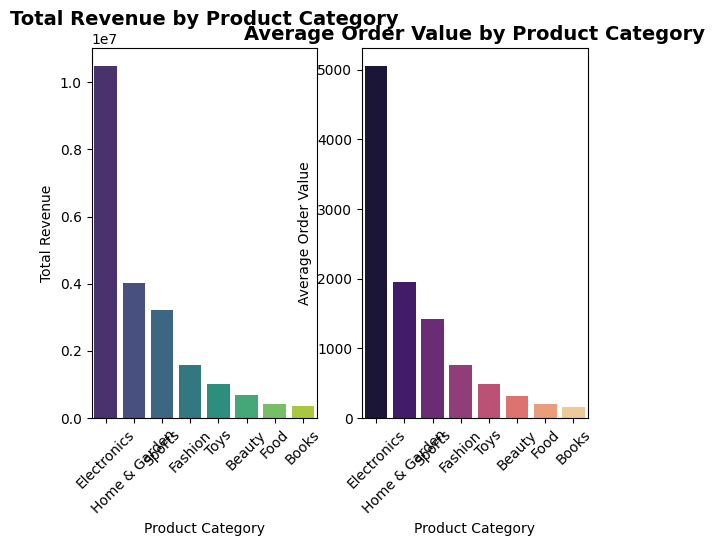

In [18]:
category_stats = category_stats.sort_values('Total_Revenue', ascending=False)
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.barplot(x=category_stats.index, y=category_stats['Total_Revenue'], palette='viridis')
plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.barplot(x=category_stats.index, y=category_stats['Avg_Order_Value'], palette='magma')
plt.title('Average Order Value by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)
plt.show()

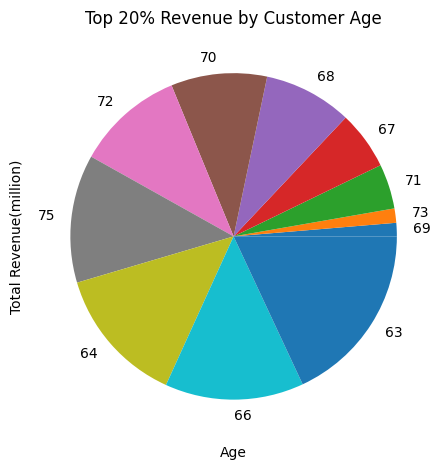

In [19]:
age_revenue = df.groupby('Age')['Total_Amount'].sum().sort_values(ascending=True)
topcount = int(len(age_revenue) * 0.2)
df_top = age_revenue.head(max(1, topcount))
df_top.plot(kind='pie', color='skyblue')
plt.title('Top 20% Revenue by Customer Age')
plt.xlabel('Age')
plt.ylabel('Total Revenue(million)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

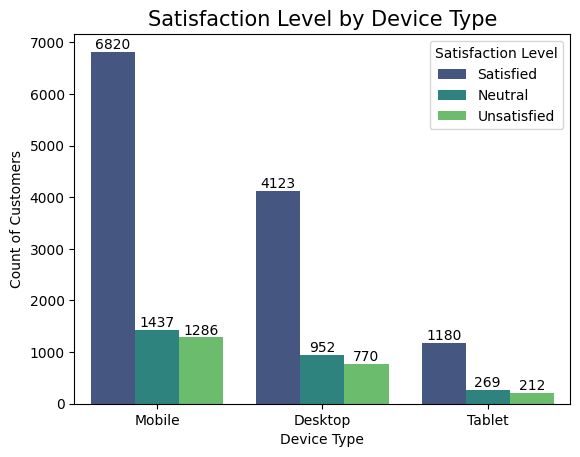

In [20]:
def get_satisfaction(rating):
    if rating >= 4:
        return 'Satisfied'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Unsatisfied'
df['Satisfaction_Level'] = df['Customer_Rating'].apply(get_satisfaction)
sk = sns.countplot(data=df, x='Device_Type', hue='Satisfaction_Level',
                   hue_order=['Satisfied', 'Neutral', 'Unsatisfied'],
                   palette='viridis')
plt.title('Satisfaction Level by Device Type',size = '15')
plt.xlabel('Device Type')
plt.ylabel('Count of Customers')
plt.legend(title='Satisfaction Level')
for container in sk.containers:
    sk.bar_label(container)
plt.show()

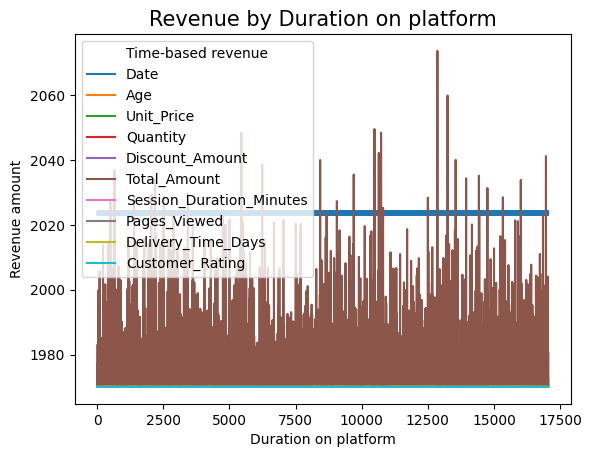

In [21]:
df.groupby('Session_Duration_Minutes')['Total_Amount'].sum()
df.plot(kind='line')
plt.title('Revenue by Duration on platform',size = '15')
plt.xlabel('Duration on platform')
plt.ylabel('Revenue amount')
plt.legend(title='Time-based revenue')
plt.show()

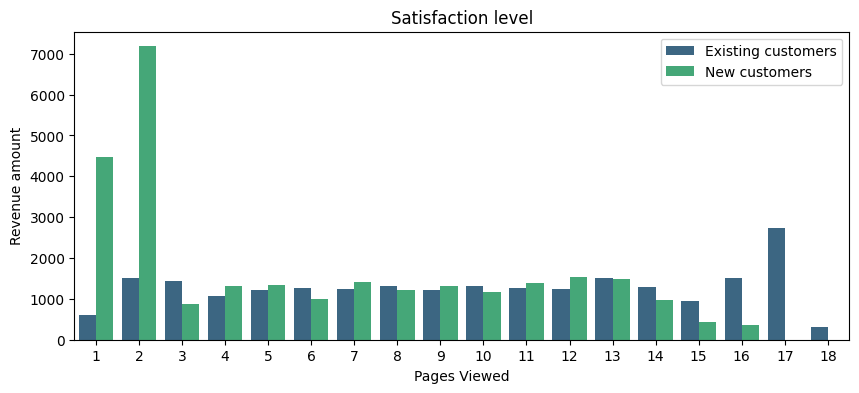

In [22]:
def get_customer(customertype):
    if customertype == True:
        return 'Existing customers'
    else:
        return 'New customers'
plt.figure(figsize=(10, 4))
df['Customer_Type'] = df['Is_Returning_Customer'].apply(get_customer)
ax = sns.barplot(data=df, x='Pages_Viewed', y='Total_Amount', hue='Customer_Type', errorbar=None, palette='viridis')
plt.title('Revenue by Pagesview',size = '15')
plt.xlabel('Pages Viewed')
plt.ylabel('Revenue amount')
plt.title('Satisfaction level')
plt.legend()
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
numerical_features = ['Age','Quantity','Total_Amount','Session_Duration_Minutes','Pages_Viewed','Customer_Rating']
categorical_features = ['Gender','City','Payment_Method','Device_Type','Is_Returning_Customer','Satisfaction_Level']
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])
df_processed = preprocessor.fit_transform(df)
print("Shape of processed data:", df_processed.shape)

Shape of processed data: (17049, 32)


In [ ]:
from sklearn.cluster import KMeans
sum_of_squared_distances = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_processed)
    sum_of_squared_distances.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.title('Elbow Method For Optimal k')
plt.show()


In [ ]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_processed)
print(df.head())


In [ ]:
cluster_product_distribution = df.groupby(['Cluster', 'Product_Category']).size().unstack(fill_value=0)
plt.figure(figsize=(12, 7))
cluster_product_distribution.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Distribution of Clusters by Product Category', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()